In [10]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from utils import read_video, save_video 
import sklearn.cluster 
from sklearn.cluster import KMeans


In [2]:
# make sure the path is a string; use a raw string to avoid escape-sequence issues
image_path = r"D:\football_analysis\output_videos\cropped_img.jpg"

In [3]:
image = cv2.imread(image_path)

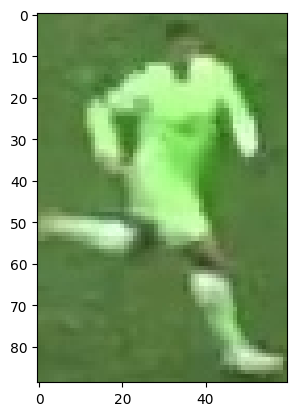

In [4]:
image=cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)


take the top part of the image

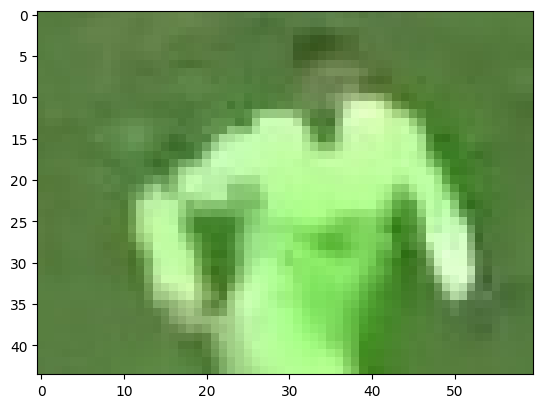

In [7]:
top_half_image = image[0:image.shape[0]//2, :, :]
plt.imshow(top_half_image)

Cluster the image into 2 clusters

In [26]:
print(top_half_image.shape)
image_2d= top_half_image.reshape((-1,3))




(44, 60, 3)


In [17]:
kmeans=KMeans(n_clusters=2, random_state=0).fit(image_2d)

#get th cluster labels

In [20]:
labels = kmeans.labels_

#reshape
clustered_image = labels.reshape(top_half_image.shape[0], top_half_image.shape[1])

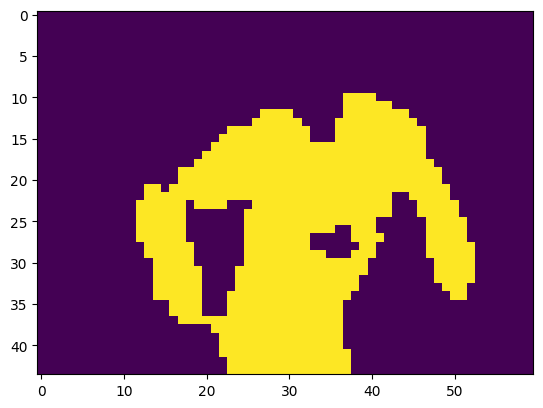

In [21]:
plt.imshow(clustered_image)

In [23]:
clustered_image.shape

(44, 60)

In [27]:
corner_clusters= [clustered_image[0,0], clustered_image[0,-1], clustered_image[-1,0], clustered_image[-1,-1]]

In [28]:
corner_clusters

[np.int32(0), np.int32(0), np.int32(0), np.int32(0)]

In [29]:
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)

In [30]:
print(non_player_cluster)

0


In [31]:
player_cluster= 1 - non_player_cluster

In [32]:
kmeans.cluster_centers_[player_cluster]

array([171.18302387, 235.90848806, 142.85278515])